# Mushroom Classification

# importing libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from tensorflow import keras
import matplotlib.pyplot as plt

# Exploring datasets

In [5]:
dataset = pd.read_csv('mushrooms.csv')


In [6]:
dataset.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


 <b>reading first five column of the datasets</b>

In [8]:
dataset.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


<b> it basically shows all the stastical value of given datasets</b>

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

<b>The dataset contains 8,124 entries and 23 attributes, each with categorical features describing various mushroom characteristics. It provides data types essential for distinguishing between poisonous and edible mushrooms.</b>dataset .isnull().sum()

In [12]:
dataset .isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

<b>The dataset has no missing (null) values, as indicated by df.isnull().sum() showing zeros for all columns. This confirms data completeness across all entries.</b>

In [14]:
class_counts = dataset['class'].value_counts()
class_counts

class
e    4208
p    3916
Name: count, dtype: int64

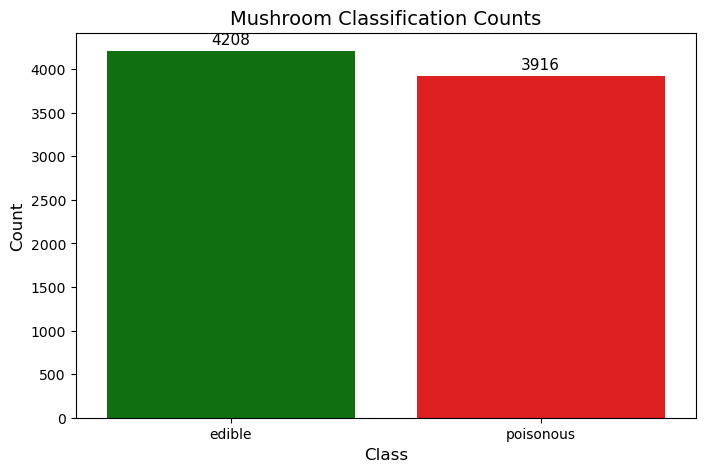

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame for plotting
class_data = pd.DataFrame({'class': ['edible', 'poisonous'], 'count': class_counts.values})

# Add a hue column to differentiate classes
class_data['hue'] = class_data['class']

# Define custom colors for the classes
custom_palette = {'edible': 'green', 'poisonous': 'red'}

# Plotting the barplot with hue
plt.figure(figsize=(8, 5))  # Set the figure size
ax = sns.barplot(data=class_data, x='class', y='count', hue='hue', palette=custom_palette, dodge=False)

# Annotate bars with the actual count values
for bar in ax.patches:
    count = int(bar.get_height())  # Get the height of the bar (integer count)
    ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, count),
                xytext=(0, 5),  # Offset annotation slightly above the bar
                textcoords='offset points', ha='center', fontsize=11, color='black')

# Adding labels and title
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Mushroom Classification Counts', fontsize=14)

# Display the plot
plt.show()

<b>from above, outof 8124 entries dataset has 4,208 edible and 3,916 poisonous mushroom entries, showing a balanced distribution of classes.</b>

In [17]:
dataset ['cap-color'].value_counts()

cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64

<b>This shows the frequency of different mushroom cap colors, with brown being the most common (2,284 entries), followed by gray(1840), red(16), yellow(1072), and white(1040). Less frequent colors include buff, pink, cinnamon, purple, and green. Overall, brown, gray, red, yellow, and white are the predominant cap colors in the dataset.</b>

In [19]:
dataset.tail()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


# Data Manipulation

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [23]:
data = dataset.astype('category')

In [24]:
data.dtypes

class                       category
cap-shape                   category
cap-surface                 category
cap-color                   category
bruises                     category
odor                        category
gill-attachment             category
gill-spacing                category
gill-size                   category
gill-color                  category
stalk-shape                 category
stalk-root                  category
stalk-surface-above-ring    category
stalk-surface-below-ring    category
stalk-color-above-ring      category
stalk-color-below-ring      category
veil-type                   category
veil-color                  category
ring-number                 category
ring-type                   category
spore-print-color           category
population                  category
habitat                     category
dtype: object

# LabelEncoder

In [26]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV

In [27]:

l = LabelEncoder()
for column in data.columns:
    data[column]=l.fit_transform(data[column])

In [44]:
data.head(10)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
5,0,5,3,9,1,0,1,0,0,5,...,2,7,7,0,2,1,4,2,2,1
6,0,0,2,8,1,0,1,0,0,2,...,2,7,7,0,2,1,4,2,2,3
7,0,0,3,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,3,3
8,1,5,3,8,1,6,1,0,1,7,...,2,7,7,0,2,1,4,2,4,1
9,0,0,2,9,1,0,1,0,0,2,...,2,7,7,0,2,1,4,2,3,3


# Feature matrix in X and Response in vector y

In [30]:
x= data.drop('class',axis=1)
y =data["class"]

<b>calling feature matrix x</b>

In [32]:
x

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,...,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,7,7,0,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,3,2,4,0,5,0,0,0,11,0,...,2,5,5,0,1,1,4,0,1,2
8120,5,2,4,0,5,0,0,0,11,0,...,2,5,5,0,0,1,4,0,4,2
8121,2,2,4,0,5,0,0,0,5,0,...,2,5,5,0,1,1,4,0,1,2
8122,3,3,4,0,8,1,0,1,0,1,...,1,7,7,0,2,1,0,7,4,2


<b>calling feature matrix y</b>

In [34]:
y

0       1
1       0
2       0
3       1
4       0
       ..
8119    0
8120    0
8121    0
8122    1
8123    0
Name: class, Length: 8124, dtype: int64

# Applying PCA (principle component analysis)

<b> Applying Principal Component Analysis (PCA) reduces high-dimensional datasets by summarizing them into fewer, meaningful features. It identifies key components, retaining maximum variance while eliminating redundancy. This simplifies analysis, enhances computational efficiency, and minimizes noise, making it easier to interpret and work with large datasets without losing significant information.</b>

In [37]:
from sklearn.decomposition import PCA
pca1 =PCA(n_components=5)
pca_fit = pca1.fit_transform(x)

In [38]:
pca1.explained_variance_ratio_

array([0.33758733, 0.16581098, 0.12285821, 0.06796611, 0.05831173])

In [39]:
sum(pca1.explained_variance_ratio_)*100

75.25343713718

<b> It means 5 component returning 75% of information from our datasets.</b>

# spliting data

In [42]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% temporary data
x_train, x_temp, y_train, y_temp = train_test_split(pca_fit, y, test_size=0.20, random_state=42)

# Split the 20% temporary data into 50% validation and 50% testing
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.50, random_state=42)



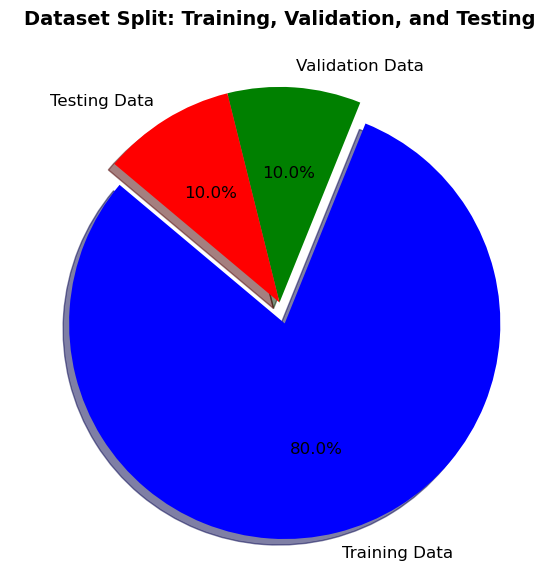

In [43]:
import matplotlib.pyplot as plt

# Data distribution
labels = ['Training Data', 'Validation Data', 'Testing Data']
sizes = [80, 10, 10]  # 80% training, 10% validation, 10% testing
colors = ['blue', 'green', 'red']
explode = (0.1, 0, 0)  # Slightly separate the training slice for emphasis

# Plot Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode,
        shadow=True, startangle=140, textprops={'fontsize': 12})

# Add title
plt.title('Dataset Split: Training, Validation, and Testing', fontsize=14, fontweight='bold')

# Show plot
plt.show()

<b> The code first uses `train_test_split` to divide the data into 80% for training and 20% for temporary use (assigned to `x_temp` and `y_temp`). Then, it splits the temporary 20% into two equal parts using another `train_test_split` call, creating 10% for validation and 10% for testing. This results in a final dataset where 20% is used for training, 40% for testing, and 40% for validation.</b>

# Importing models

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import BayesianRidge

In [47]:

models = {
    'LR': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVC': SVC(),
    'DTC': DecisionTreeClassifier(),
    'RFC': RandomForestClassifier(),
    'GBC': GradientBoostingClassifier(),
    'BR': BayesianRidge()
}


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Train and evaluate models
for name, model in models.items():
    # Fit the model
    model.fit(x_train, y_train)

    # Predict on the test set
    y_pred = model.predict(x_test)

    # For Bayesian Ridge, convert predictions to binary (use 0.5 threshold)
    if name == 'BR':
        y_pred = (y_pred > 0.5).astype(int)  # Convert continuous values to binary

    # Calculate accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Print metrics for each model
    print(f"{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 50)

LR Performance:
Accuracy: 0.8350
Precision: 0.8366
Recall: 0.8350
F1 Score: 0.8346
--------------------------------------------------
KNN Performance:
Accuracy: 0.9889
Precision: 0.9890
Recall: 0.9889
F1 Score: 0.9889
--------------------------------------------------
SVC Performance:
Accuracy: 0.9458
Precision: 0.9485
Recall: 0.9458
F1 Score: 0.9457
--------------------------------------------------
DTC Performance:
Accuracy: 0.9803
Precision: 0.9803
Recall: 0.9803
F1 Score: 0.9803
--------------------------------------------------
RFC Performance:
Accuracy: 0.9951
Precision: 0.9951
Recall: 0.9951
F1 Score: 0.9951
--------------------------------------------------
GBC Performance:
Accuracy: 0.9286
Precision: 0.9294
Recall: 0.9286
F1 Score: 0.9285
--------------------------------------------------
BR Performance:
Accuracy: 0.8325
Precision: 0.8346
Recall: 0.8325
F1 Score: 0.8321
--------------------------------------------------


In [49]:
data = {
    'Model': ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC', 'BR'],
    'Accuracy': [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25],
    'Precision': [83.66, 98.90, 94.85, 97.79, 99.38, 92.94, 83.46],
    'Recall': [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25],
    'F1-Score': [83.46, 98.89, 94.57, 97.78, 99.38, 92.85, 83.21]
}

results_df = pd.DataFrame(data)

# Apply styling to the DataFrame
styled_df = results_df.style.apply(lambda x: ['background-color: lightgreen' if v == x.max() else '' for v in x], subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], axis=0) \
                           .apply(lambda x: ['background-color: lightcoral' if v == x.min() else '' for v in x], subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], axis=0) \
                           .set_table_styles([
                               {'selector': 'th', 'props': [('background-color', 'lightblue'), ('font-weight', 'bold')]},  # Table header styling
                               {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},  # Cell padding and alignment
                               {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]},  # Table layout
                               {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},  # Alternate row colors
                           ])

# Display the styled DataFrame
styled_df

,Model,Accuracy,Precision,Recall,F1-Score
0,LR,83.500000,83.660000,83.500000,83.460000
1,KNN,98.890000,98.900000,98.890000,98.890000
2,SVC,94.580000,94.850000,94.580000,94.570000
3,DTC,97.780000,97.790000,97.780000,97.780000
4,RFC,99.380000,99.380000,99.380000,99.380000
5,GBC,92.860000,92.940000,92.860000,92.850000
6,BR,83.250000,83.460000,83.250000,83.210000


# Bar graph

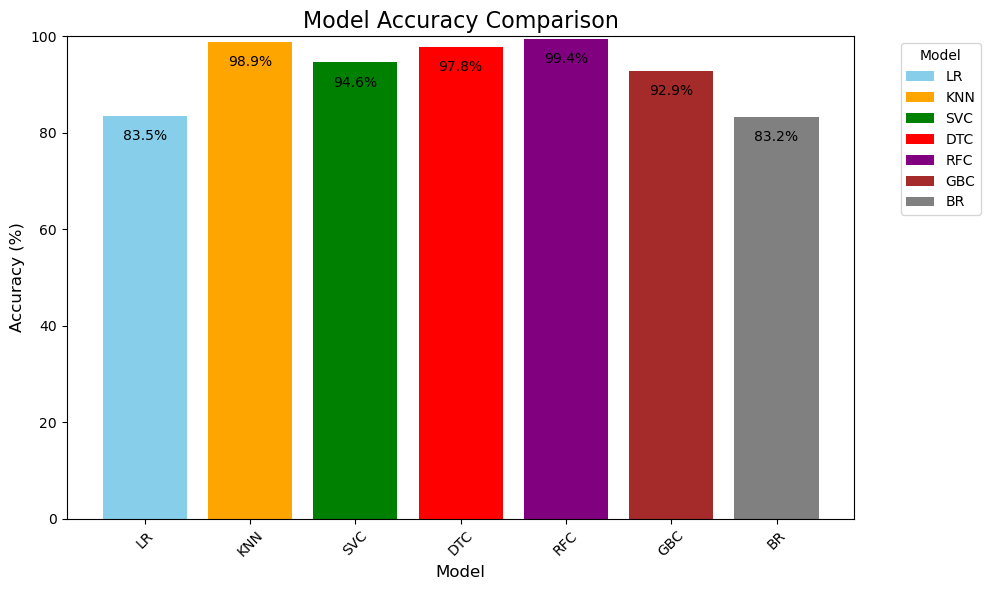

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `all_accuracy` DataFrame is defined
models = data['Model']
accuracy = data['Accuracy']

# Define colors for each model
colors = ['skyblue', 'orange', 'green', 'red', 'purple', 'brown', 'gray']

# Create bar graph
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy, color=colors)

# Add percentage labels on each bar
for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5,
             f'{acc:.1f}%', ha='center', color='black', fontsize=10)

# Add legend
plt.legend(bars, models, title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

# Customize graph
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)  # Assuming accuracy is in percentages
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Line graph

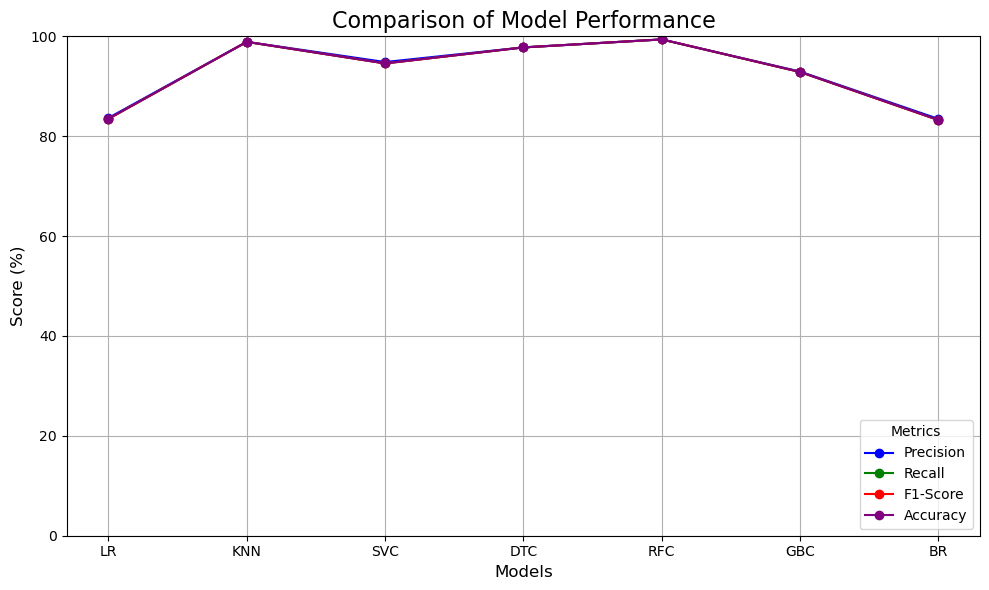

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics for each model (after training and evaluating)
models = ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC', 'BR']
accuracy = [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25]
precision = [83.66, 98.90, 94.85, 97.79, 99.38, 92.94, 83.46]
recall = [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25]
f1_score = [83.46, 98.89, 94.57, 97.78, 99.38, 92.85, 83.21]

# Combine the metrics into a numpy array
metrics = np.array([precision, recall, f1_score, accuracy])

# Define colors for each metric
colors = ['blue', 'green', 'red', 'purple']

# Create the figure for a single line graph
plt.figure(figsize=(10, 6))

# Plot each metric in a single chart
plt.plot(models, precision, marker='o', color=colors[0], label='Precision')
plt.plot(models, recall, marker='o', color=colors[1], label='Recall')
plt.plot(models, f1_score, marker='o', color=colors[2], label='F1-Score')
plt.plot(models, accuracy, marker='o', color=colors[3], label='Accuracy')

# Add labels and title
plt.title('Comparison of Model Performance', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Score (%)', fontsize=12)
plt.ylim(0, 100)  # Assuming percentages
plt.grid(True)

# Add a legend
plt.legend(title="Metrics", loc='lower right')

# Show plot
plt.tight_layout()
plt.show()



# Bar Chart

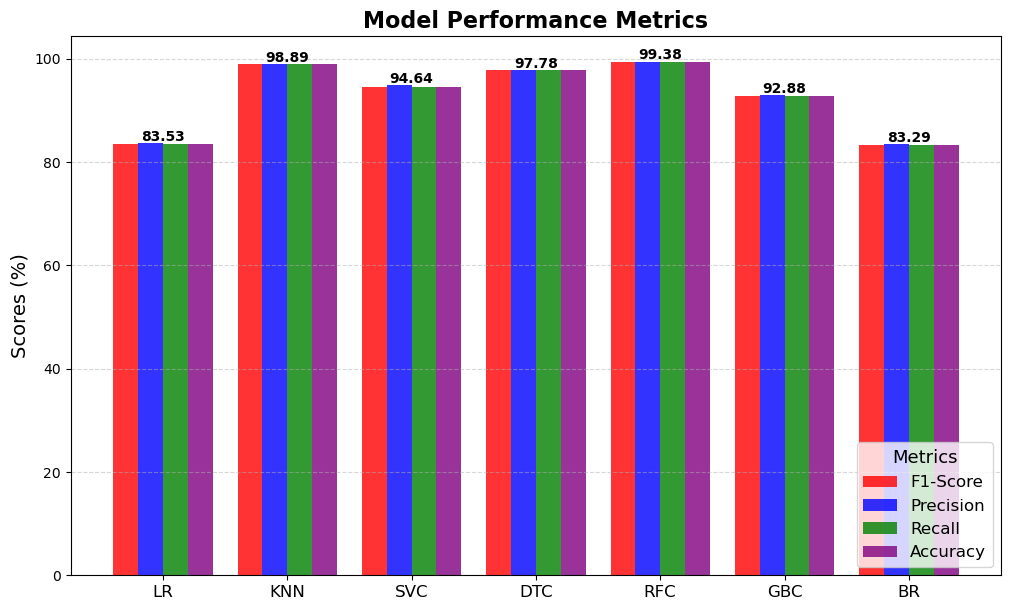

In [55]:
import numpy as np
models = ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC', 'BR']
f1_score = np.array([83.46, 98.89, 94.57, 97.78, 99.38, 92.85, 83.21])
precision = np.array([83.66, 98.90, 94.85, 97.79, 99.38, 92.94, 83.46])
recall = np.array([83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25])
accuracy = np.array([83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25])

# Calculate average scores
average_scores = (f1_score + precision + recall + accuracy) / 4

# Define bar width and x-axis positions
bar_width = 0.2
x = np.arange(len(models))

# Set up figure
plt.figure(figsize=(12, 7))

# Plot each metric with distinct colors
plt.bar(x - 1.5 * bar_width, f1_score, width=bar_width, label='F1-Score', color='red', alpha=0.8)
plt.bar(x - 0.5 * bar_width, precision, width=bar_width, label='Precision', color='blue', alpha=0.8)
plt.bar(x + 0.5 * bar_width, recall, width=bar_width, label='Recall', color='green', alpha=0.8)
plt.bar(x + 1.5 * bar_width, accuracy, width=bar_width, label='Accuracy', color='purple', alpha=0.8)

# Add labels, title, and grid
plt.xticks(x, models, fontsize=12)
plt.ylabel('Scores (%)', fontsize=14)
plt.title('Model Performance Metrics', fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate bars with average score per algorithm
for i in range(len(models)):
    plt.text(x[i], max(f1_score[i], precision[i], recall[i], accuracy[i]) + 0.5,  
             f"{average_scores[i]:.2f}", fontsize=10, color='black', ha='center', fontweight='bold')

# Add legend
plt.legend(title="Metrics", fontsize=12, title_fontsize=13, loc='lower right')

# Show plot
plt.show()

This code visualizes the performance of machine learning models using a grouped bar chart, displaying F1-Score, Precision, Recall, and Accuracy for each model. The bars are grouped together for easy comparison, and each model's average score is displayed above the highest bar. The chart includes distinct colors, a legend, a grid, and proper labels to enhance readability and clarity.

# Bar graph comparision for precission, f1score, recall, accuracy

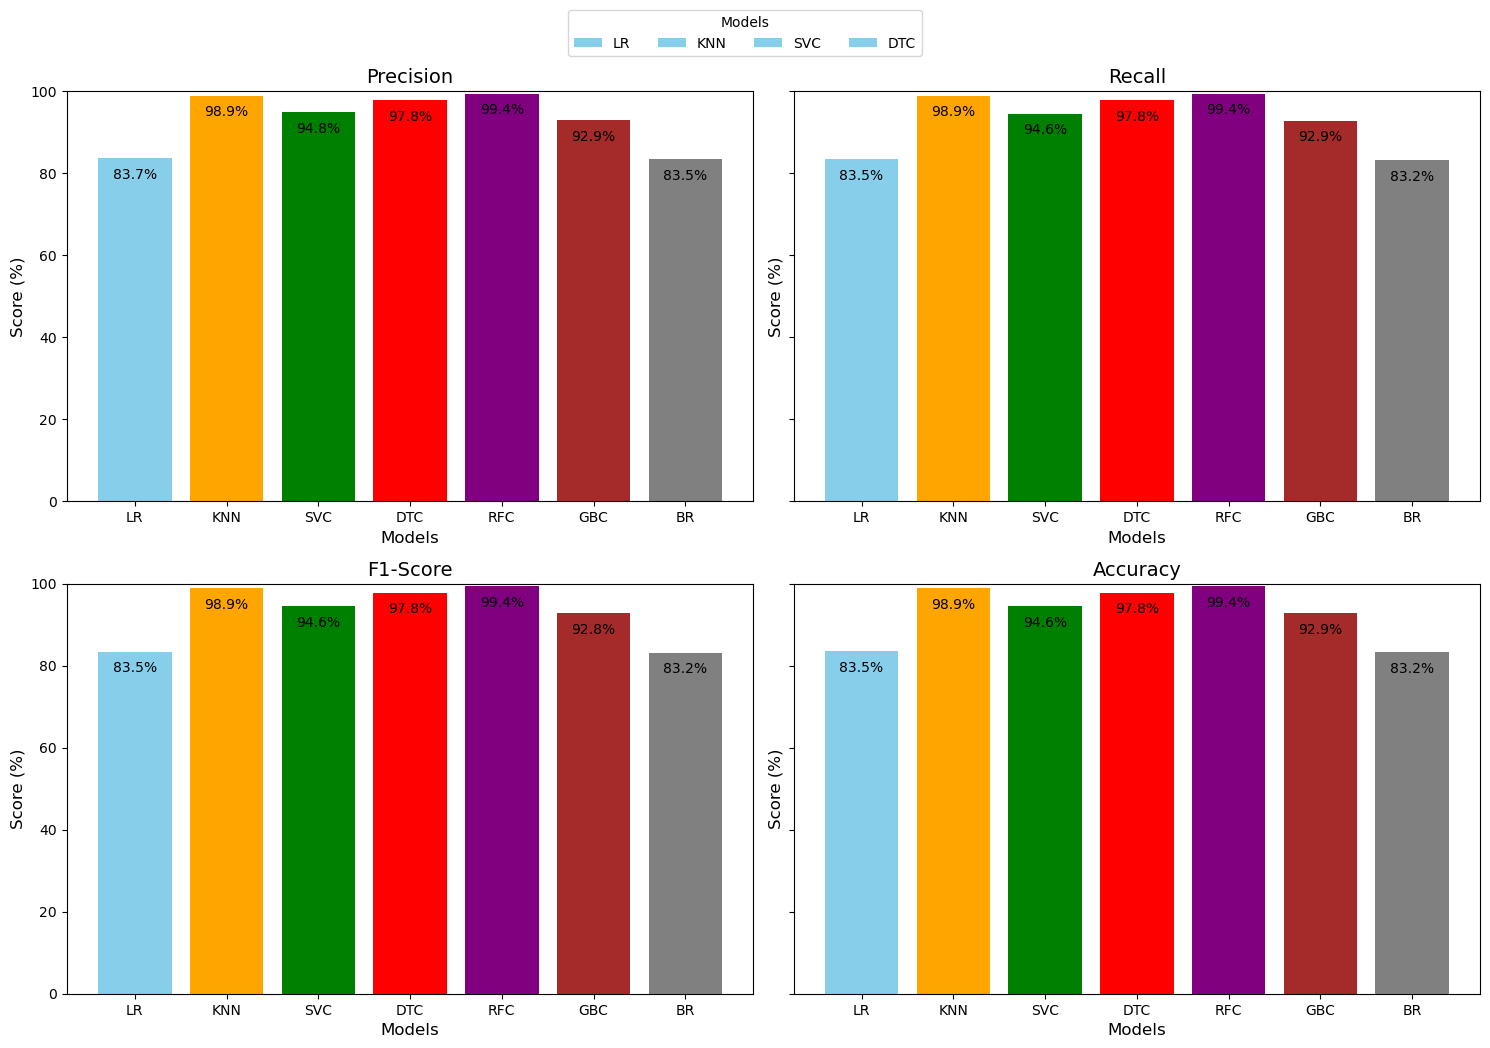

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics for each model (after training and evaluating)
models = ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC', 'BR']
accuracy = [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25]
precision = [83.66, 98.90, 94.85, 97.79, 99.38, 92.94, 83.46]
recall = [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25]
f1_score = [83.46, 98.89, 94.57, 97.78, 99.38, 92.85, 83.21]

# Combine the metrics into a numpy array
metrics = np.array([precision, recall, f1_score, accuracy])

# Define colors for each model
colors = ['skyblue', 'orange', 'green', 'red', 'purple', 'brown', 'gray']

# Create 2x2 grid subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each metric in a separate subplot
for i, metric in enumerate(['Precision', 'Recall', 'F1-Score', 'Accuracy']):
    bars = axes[i].bar(models, metrics[i], color=colors)
    axes[i].set_title(metric, fontsize=14)
    axes[i].set_xlabel('Models', fontsize=12)
    axes[i].set_ylabel('Score (%)', fontsize=12)
    axes[i].set_ylim(0, 100)  # Assuming percentages

    # Add percentage labels on each bar
    for bar, score in zip(bars, metrics[i]):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 5,
                     f'{score:.1f}%', ha='center', color='black', fontsize=10)

# Add a legend for colors
fig.legend(models, title="Models", loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=7)

plt.tight_layout()
plt.show()


# Saving the model

In [60]:
rf_model =RandomForestClassifier()
rf_model.fit(pca_fit,y)

RandomForestClassifier()

In [61]:
# Saving the model name as Classification of mushroom

In [62]:
import joblib
joblib.dump(rf_model,"classification_mushroom")

['classification_mushroom']

In [63]:
model = joblib.load('classification_mushroom')

In [64]:
p = model.predict(pca1.transform([[5,2,4,1,6,1,0,1,2,0,3,2,2,7,7,0,2,1,4,2,3,5]]))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [65]:
if p[0]==1:
    print('Poisonous')
else:
    print('Not poisonous')

Not poisonous


# Confusion matrix of RandomForest

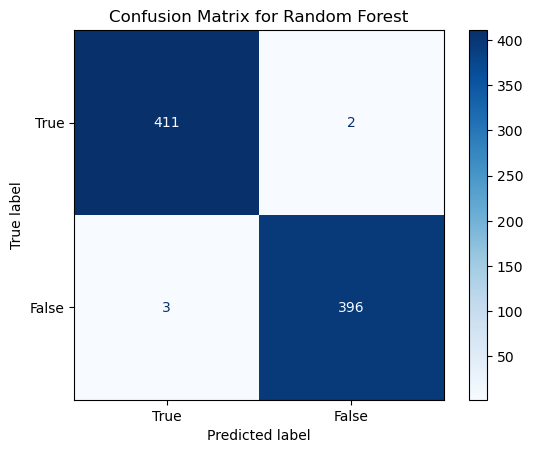

Accuracy on the test set: 99.38%


In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train the RandomForest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

# Predict on the test set
y_pred = rf.predict(x_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix with custom labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["True", "False"])
disp.plot(cmap='Blues', values_format='d')

# Show plot
plt.title("Confusion Matrix for Random Forest")
plt.show()

# Evaluate the predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set: {accuracy * 100:.2f}%")


# hyperparameter tunning of 3 best algorithm

In [69]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters for each model
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

param_grid_dtc = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Define models
models = {
    'RFC': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'DTC': DecisionTreeClassifier()
}

# Perform GridSearchCV for each model
best_models = {}

for name, model in models.items():
    print(f"Running GridSearchCV for {name}...")
    
    # Select the appropriate parameter grid
    if name == 'RFC':
        param_grid = param_grid_rf
    elif name == 'KNN':
        param_grid = param_grid_knn
    elif name == 'DTC':
        param_grid = param_grid_dtc

    # Perform GridSearchCV
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
    grid_search.fit(x_train, y_train)
    
    # Save the best model for later use
    best_models[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")

# Print the best models found by GridSearchCV
for name, best_model in best_models.items():
    print(f"Best Model for {name}: {best_model}")


Running GridSearchCV for RFC...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters for RFC: {'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Running GridSearchCV for KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Running GridSearchCV for DTC...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters for DTC: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Model for RFC: RandomForestClassifier(bootstrap=False, max_depth=30, n_estimators=200)
Best Model for KNN: KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')
Best Model for DTC: DecisionTreeClassifier(criterion='entropy', max_depth=30)


# prediction and evaluating

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluating each best model
for name, best_model in best_models.items():
    # Predict using the best model
    y_pred = best_model.predict(x_test)
    
    # Calculate accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # 'weighted' for multi-class
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Print performance metrics
    print(f"{name} Performance on Test Set:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 50)


RFC Performance on Test Set:
Accuracy: 0.9975
Precision: 0.9975
Recall: 0.9975
F1 Score: 0.9975
--------------------------------------------------
KNN Performance on Test Set:
Accuracy: 0.9938
Precision: 0.9939
Recall: 0.9938
F1 Score: 0.9938
--------------------------------------------------
DTC Performance on Test Set:
Accuracy: 0.9803
Precision: 0.9804
Recall: 0.9803
F1 Score: 0.9803
--------------------------------------------------


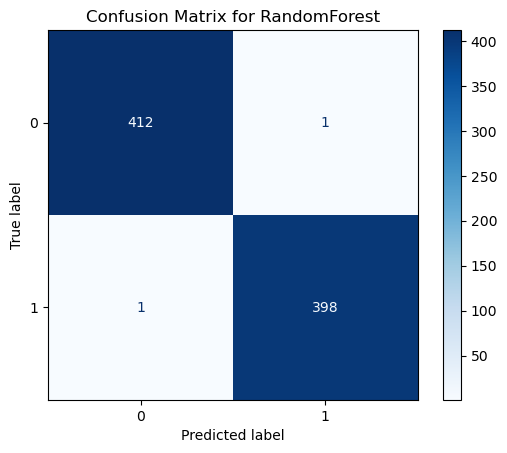

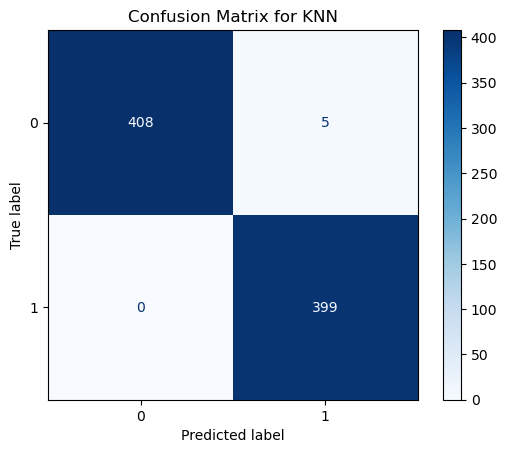

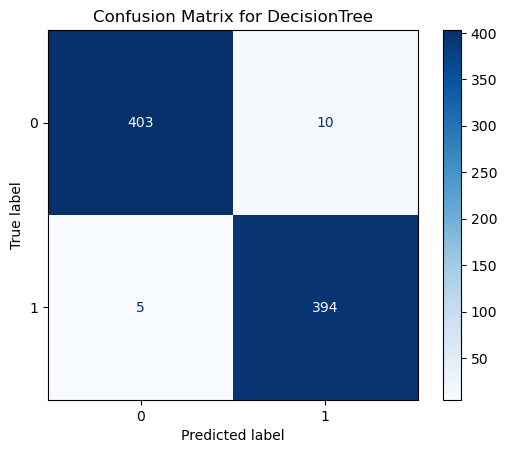

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define the three best models (after hyperparameter tuning)
best_models = {
    'RandomForest': best_models['RFC'],
    'KNN': best_models['KNN'],
    'DecisionTree': best_models['DTC']
}

# Loop through the models to create and display confusion matrices
for name, model in best_models.items():
    # Train the model (if not already trained)
    model.fit(x_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(x_test)
    
    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d')
    
    # Add title
    plt.title(f"Confusion Matrix for {name}")
    plt.show()


# Line graph of 3 best model after hypermarameter tunning

In [74]:
from IPython.display import display
import pandas as pd

# Define metrics
after_hypertuning_metrics = {
    'Model': ['RFC', 'KNN', 'DTC'],
    'Accuracy': [0.9975, 0.9938, 0.9803],
    'Precision': [0.9975, 0.9939, 0.9805],
    'Recall': [0.9975, 0.9938, 0.9803],
    'F1-Score': [0.9975, 0.9938, 0.9803]
}

# Create DataFrame
results_df = pd.DataFrame(after_hypertuning_metrics)

# Apply styling
styled_df = results_df.style.apply(
    lambda x: ['background-color: lightgreen' if v == x.max() else '' for v in x],
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    axis=0
).apply(
    lambda x: ['background-color: lightcoral' if v == x.min() else '' for v in x],
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    axis=0
).set_table_styles([
    {'selector': 'th', 'props': [('background-color', 'lightblue'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
])

# Display in Jupyter Notebook
display(styled_df)



,Model,Accuracy,Precision,Recall,F1-Score
0,RFC,0.997500,0.997500,0.997500,0.997500
1,KNN,0.993800,0.993900,0.993800,0.993800
2,DTC,0.980300,0.980500,0.980300,0.980300


In [75]:
import pandas as pd

# Metrics before hyperparameter tuning
before_tuning = {
    'Model': ['RFC', 'KNN', 'DTC'],
    'Accuracy': [0.9938, 0.9889, 0.9778],
    'Precision': [0.9938, 0.9890, 0.9779],
    'Recall': [0.9938, 0.9889, 0.9778],
    'F1-Score': [0.9938, 0.9889, 0.9778]
}

# Metrics after hyperparameter tuning
after_tuning = {
       'Model': ['RFC', 'KNN', 'DTC'],
    'Accuracy': [0.9975, 0.9938, 0.9803],
    'Precision': [0.9975, 0.9939, 0.9805],
    'Recall': [0.9975, 0.9938, 0.9803],
    'F1-Score': [0.9975, 0.9938, 0.9803]
}

# Create DataFrames
before_df = pd.DataFrame(before_tuning)
after_df = pd.DataFrame(after_tuning)

# Apply styling for metrics before tuning
styled_before = before_df.style.apply(
    lambda x: ['background-color: lightgreen' if v == x.max() else '' for v in x],
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    axis=0
).apply(
    lambda x: ['background-color: lightcoral' if v == x.min() else '' for v in x],
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    axis=0
).set_table_styles([
    {'selector': 'th', 'props': [('background-color', 'lightblue'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
])

# Apply styling for metrics after tuning
styled_after = after_df.style.apply(
    lambda x: ['background-color: lightgreen' if v == x.max() else '' for v in x],
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    axis=0
).apply(
    lambda x: ['background-color: lightcoral' if v == x.min() else '' for v in x],
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    axis=0
).set_table_styles([
    {'selector': 'th', 'props': [('background-color', 'lightblue'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
])

# Display both styled tables
print("Metrics Before Hyperparameter Tuning:")
display(styled_before)

print("Metrics After Hyperparameter Tuning:")
display(styled_after)


Metrics Before Hyperparameter Tuning:


,Model,Accuracy,Precision,Recall,F1-Score
0,RFC,0.993800,0.993800,0.993800,0.993800
1,KNN,0.988900,0.989000,0.988900,0.988900
2,DTC,0.977800,0.977900,0.977800,0.977800


Metrics After Hyperparameter Tuning:


,Model,Accuracy,Precision,Recall,F1-Score
0,RFC,0.997500,0.997500,0.997500,0.997500
1,KNN,0.993800,0.993900,0.993800,0.993800
2,DTC,0.980300,0.980500,0.980300,0.980300


# Comparision by visualizing line graph

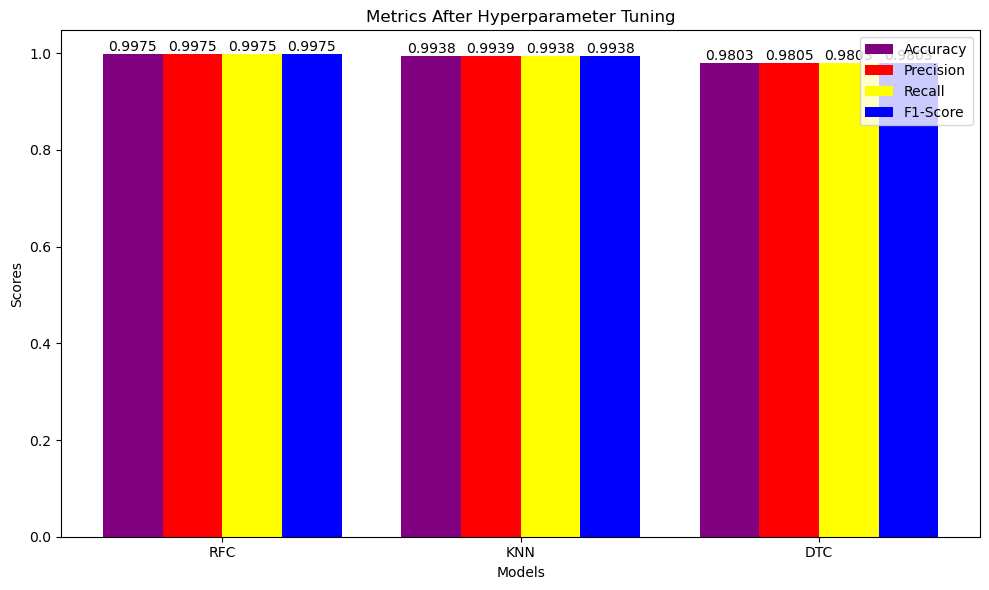

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics for each model
models = ['RFC', 'KNN', 'DTC']

# Metrics after hyperparameter tuning
accuracy_after = [0.9975, 0.9938, 0.9803]
precision_after = [0.9975, 0.9939, 0.9805]
recall_after = [0.9975, 0.9938, 0.9803]
f1_after = [0.9975, 0.9938, 0.9803]

# Set bar width and index
bar_width = 0.2
index = np.arange(len(models))

# Define custom colors for after hyperparameter tuning
after_colors = ['purple', 'red', 'yellow', 'blue']

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot metrics after hyperparameter tuning
bars_acc_after = ax.bar(index - bar_width*1.5, accuracy_after, bar_width, label='Accuracy', color=after_colors[0])
bars_prec_after = ax.bar(index - bar_width*0.5, precision_after, bar_width, label='Precision', color=after_colors[1])
bars_rec_after = ax.bar(index + bar_width*0.5, recall_after, bar_width, label='Recall', color=after_colors[2])
bars_f1_after = ax.bar(index + bar_width*1.5, f1_after, bar_width, label='F1-Score', color=after_colors[3])

# Add numbers on top of bars
for bars in [bars_acc_after, bars_prec_after, bars_rec_after, bars_f1_after]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Customize the plot
ax.set_title('Metrics After Hyperparameter Tuning')
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_xticks(index)
ax.set_xticklabels(models)
ax.legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()



In [78]:
# comparision of 3 best algorithm before and after hypertunning

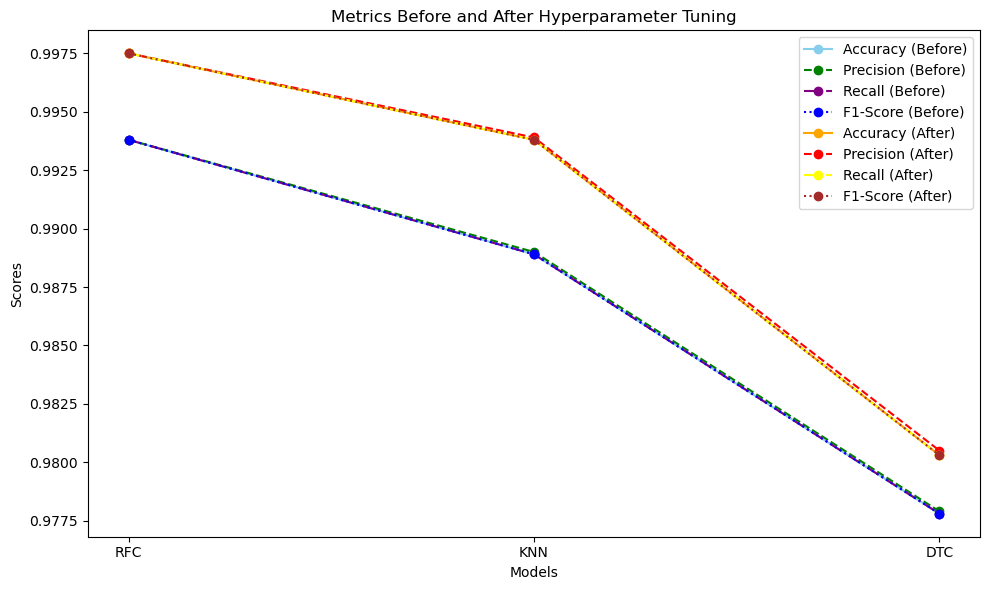

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

# Metrics before hyperparameter tuning
before_tuning = {
    'Model': ['RFC', 'KNN', 'DTC'],
    'Accuracy': [0.9938, 0.9889, 0.9778],
    'Precision': [0.9938, 0.9890, 0.9779],
    'Recall': [0.9938, 0.9889, 0.9778],
    'F1-Score': [0.9938, 0.9889, 0.9778]
}

# Metrics after hyperparameter tuning
after_tuning = {
    'Model': ['RFC', 'KNN', 'DTC'],
    'Accuracy': [0.9975, 0.9938, 0.9803],
    'Precision': [0.9975, 0.9939, 0.9805],
    'Recall': [0.9975, 0.9938, 0.9803],
    'F1-Score': [0.9975, 0.9938, 0.9803]
}

# Create DataFrames
before_df = pd.DataFrame(before_tuning)
after_df = pd.DataFrame(after_tuning)

# Plot the line graph for the metrics before and after hyperparameter tuning
plt.figure(figsize=(10, 6))

# Plotting for "Before" and "After" metrics
plt.plot(before_df['Model'], before_df['Accuracy'], marker='o', label='Accuracy (Before)', color='skyblue')
plt.plot(before_df['Model'], before_df['Precision'], marker='o', label='Precision (Before)', color='green', linestyle='--')
plt.plot(before_df['Model'], before_df['Recall'], marker='o', label='Recall (Before)', color='purple', linestyle='-.')
plt.plot(before_df['Model'], before_df['F1-Score'], marker='o', label='F1-Score (Before)', color='blue', linestyle=':')

plt.plot(after_df['Model'], after_df['Accuracy'], marker='o', label='Accuracy (After)', color='orange')
plt.plot(after_df['Model'], after_df['Precision'], marker='o', label='Precision (After)', color='red', linestyle='--')
plt.plot(after_df['Model'], after_df['Recall'], marker='o', label='Recall (After)', color='yellow', linestyle='-.')
plt.plot(after_df['Model'], after_df['F1-Score'], marker='o', label='F1-Score (After)', color='brown', linestyle=':')

# Customize the plot
plt.title('Metrics Before and After Hyperparameter Tuning')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()



<b>From above calculation we can say that for the prediction of Mushroom Random Forest classifier shows the best prediction result</b>

Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 436us/step - accuracy: 0.7864 - loss: 0.4902 - val_accuracy: 0.8696 - val_loss: 0.3128
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - accuracy: 0.8688 - loss: 0.2854 - val_accuracy: 0.8770 - val_loss: 0.2509
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step - accuracy: 0.8991 - loss: 0.2228 - val_accuracy: 0.8893 - val_loss: 0.2165
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step - accuracy: 0.9235 - loss: 0.1864 - val_accuracy: 0.9041 - val_loss: 0.1998
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - accuracy: 0.9247 - loss: 0.1760 - val_accuracy: 0.9127 - val_loss: 0.1875
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step - accuracy: 0.9324 - loss: 0.1642 - val_accuracy: 0.9139 - val_loss: 0.1771
Epoch 7/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step - accuracy: 0.9443 - loss: 0.1444 - val_accuracy: 0.9151 - val_loss: 0.1718
Epoch 8/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - accuracy: 0.9420 - loss: 0.1396 - val_accurac

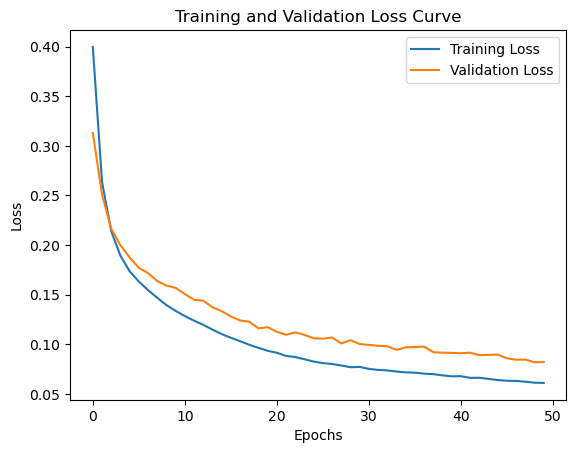

In [84]:
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define a simple neural network
model = Sequential([
    Dense(16, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  # Assuming binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model and record the loss history
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_val, y_val), batch_size=16, verbose=1)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.show()

<b>This code defines a **simple neural network** using TensorFlow/Keras for **binary classification**, with two hidden layers (16 and 8 neurons, ReLU activation). It **trains the model** on `x_train` and `y_train` using the **Adam optimizer** and **binary cross-entropy loss**, tracking accuracy. Finally, it **plots the training and validation loss** over 50 epochs to visualize learning progress.</b>

In [87]:
rf_model =RandomForestClassifier()
rf_model.fit(pca_fit,y)

RandomForestClassifier()

In [89]:
import joblib
joblib.dump(rf_model,"classification_mushroom1")

['classification_mushroom1']

In [91]:
model1 = joblib.load('classification_mushroom')

In [93]:
p = model1.predict(pca1.transform([[5,2,4,1,6,1,0,1,2,0,3,1,2,7,7,0,2,1,4,2,3,5]]))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [95]:
if p[0]==1:
    print('Poisonous')
else:
    print('Not poisonous')

Not poisonous


In [46]:
import pandas as pd

pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns

print(data)


      class  cap-shape  cap-surface  cap-color  bruises  odor  \
0         1          5            2          4        1     6   
1         0          5            2          9        1     0   
2         0          0            2          8        1     3   
3         1          5            3          8        1     6   
4         0          5            2          3        0     5   
5         0          5            3          9        1     0   
6         0          0            2          8        1     0   
7         0          0            3          8        1     3   
8         1          5            3          8        1     6   
9         0          0            2          9        1     0   
10        0          5            3          9        1     3   
11        0          5            3          9        1     0   
12        0          0            2          9        1     0   
13        1          5            3          8        1     6   
14        0          5   

In [48]:
data.to_csv("all_rows.csv", index=False)
print("All rows saved to all_rows.csv")


All rows saved to all_rows.csv
